# 0. Cargar datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Ventas

In [2]:
# Cargar datos
path_ventas = "datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv"
ventas = pd.read_csv(path_ventas)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_41014/3745035006.py:3: DtypeWarning: Columns (0: dscto_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


Ventas - Filas: 10596574


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Monto Real,Precio,venta_id,Zona,Distrito,Precio_Lista,dscto_base,dscto_volumen,dscto_binario,carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,43440,10860.000,0,SUR 3,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN
1,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,TOCINOS,...,39366,10935.000,7,SUR 3,PUNTA ARENAS,11313.0,NaN,NaN,NaN,NaN
2,2025,1,MY,ZV01,2025-01-02,1173743,NaN,38,OTROS MAYORISTAS,TOCINOS,...,321040,8026.000,9146,NORTE 2,LA SERENA,8791.0,-3.0,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1003766,NaN,32,COBERTURA,MORTADELAS,...,10860,3620.000,8790,NORTE 2,LA SERENA,3749.0,NaN,NaN,NaN,NaN
4,2025,1,MY,ZV01,2025-01-02,1037307,NaN,57,MAYORISTA B VOLUMEN,VIENESAS,...,36938,2308.625,6303,SUR 2,CHILLAN,2456.0,-6.0,NaN,NaN,NaN


In [3]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Factura Venta',
       'Factura Kilos', 'Kilo Real', 'Kilos Nc', 'Monto Nc', 'Monto Real',
       'Precio', 'venta_id', 'Zona', 'Distrito', 'Precio_Lista', 'dscto_base',
       'dscto_volumen', 'dscto_binario', 'carta_impacto'],
      dtype='str')

In [4]:
print(ventas["Kilos Nc"].isna().sum())
ventas = ventas[ventas["Kilos Nc"].isna()]

9853682


In [5]:
ventas["Nombre Consolidado"].unique()
## Filtrar solo los canales relevantes
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    "MAYORISTAS CADENAS",
    "MAYORISTA B VOLUMEN",
    "OTROS MAYORISTAS",
    "HORECA VOLUMEN",
    "OTROS HORECA",
]
ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 9639035


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Monto Real,Precio,venta_id,Zona,Distrito,Precio_Lista,dscto_base,dscto_volumen,dscto_binario,carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,43440,10860.000,0,SUR 3,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN
1,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,TOCINOS,...,39366,10935.000,7,SUR 3,PUNTA ARENAS,11313.0,NaN,NaN,NaN,NaN
2,2025,1,MY,ZV01,2025-01-02,1173743,NaN,38,OTROS MAYORISTAS,TOCINOS,...,321040,8026.000,9146,NORTE 2,LA SERENA,8791.0,-3.0,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1003766,NaN,32,COBERTURA,MORTADELAS,...,10860,3620.000,8790,NORTE 2,LA SERENA,3749.0,NaN,NaN,NaN,NaN
4,2025,1,MY,ZV01,2025-01-02,1037307,NaN,57,MAYORISTA B VOLUMEN,VIENESAS,...,36938,2308.625,6303,SUR 2,CHILLAN,2456.0,-6.0,NaN,NaN,NaN


In [6]:
# Filtrar columnas relevantes
cols_relevantes_ventas = [
    # Id Cliente
    "Cod Cliente", 
    # Info Canal
    "Cod Canal Comercial", "Cod Consolidado", "Zona", "Distrito",
    # Fecha real de la venta
    "Fecha Factura",
    # Id Producto
    "Cod SKU",
    # Info Producto
    "Nombre SKU",
    # Monto Venta
    "Monto Real",
    # Cantidad Venta
    "Kilo Real",
    # Precio real (por kg)
    "Precio",
    # Precio Lista
    "Precio_Lista",
    # Descuentos
    "dscto_base", "dscto_volumen", "dscto_binario", "carta_impacto"
    ]
ventas = ventas[cols_relevantes_ventas]
ventas.head()

,Cod Cliente,Cod Canal Comercial,Cod Consolidado,Zona,Distrito,Fecha Factura,Cod SKU,Nombre SKU,Monto Real,Kilo Real,Precio,Precio_Lista,dscto_base,dscto_volumen,dscto_binario,carta_impacto
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000,11538.0,NaN,NaN,NaN,NaN
1,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.6,10935.000,11313.0,NaN,NaN,NaN,NaN
2,1173743,MY,38,NORTE 2,LA SERENA,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.0,8026.000,8791.0,-3.0,NaN,NaN,NaN
3,1003766,CB,32,NORTE 2,LA SERENA,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.0,3620.000,3749.0,NaN,NaN,NaN,NaN
4,1037307,MY,57,SUR 2,CHILLAN,2025-01-02,8451,SALCHICHA SUREÑA WINTER 1 KG,36938,16.0,2308.625,2456.0,-6.0,NaN,NaN,NaN


In [7]:
# Contar nans por columna
nans_por_columna = ventas.isna().sum()
print("Nans por columna:")
print(nans_por_columna)

Nans por columna:
Cod Cliente                  0
Cod Canal Comercial        199
Cod Consolidado              0
Zona                    493633
Distrito                493633
Fecha Factura                0
Cod SKU                      0
Nombre SKU                   0
Monto Real                   0
Kilo Real                    0
Precio                       6
Precio_Lista               122
dscto_base             8384141
dscto_volumen          8643261
dscto_binario          7801412
carta_impacto          9636814
dtype: int64


In [8]:
# Indicar cuantas filas y columnas tiene el dataframe antes de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas antes de filtrar.")

# Filtrar datos con nans en alguna columna relevante que no sea de descuentos
ventas = ventas.dropna(subset=[col for col in cols_relevantes_ventas if col not in ["Zona", "Distrito", "dscto_base", "dscto_volumen", "dscto_binario", "carta_impacto"]])

# Indicar cuantas filas y columnas tiene el dataframe después de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas después de filtrar.")

El dataframe tiene 9639035 filas y 16 columnas antes de filtrar.
El dataframe tiene 9638708 filas y 16 columnas después de filtrar.


## 0.2. Maestro SKUs

In [9]:
# Cargar datos
path_maestro = "datos/Maestro Productos.xlsx"
maestro = pd.read_excel(path_maestro, header=2)
maestro.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [10]:
# Filtrar columnas relevantes
cols_relevantes_maestro = [
    # Id Producto
    "Material",
    # Info Producto
    "Texto breve de material",
    # Producto con peso cte?
    "Peso Var/Std",
    # Kg por Unidad
    "Neto"
]
maestro = maestro[cols_relevantes_maestro]
maestro["peso_variable"] = maestro["Peso Var/Std"] != "Peso Standard"
maestro.drop(columns="Peso Var/Std", inplace=True)
maestro.head()

,Material,Texto breve de material,Neto,peso_variable
0,20,ARROLLADO LOMO CON AJI SJ,3.172,True
1,21,ARROLLADO LOMO CORTADO SJ,2.000,False
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,0.250,False
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,0.250,False
4,27,ARROLLADO LOMO SIN AJI SJ,3.268,True


# 1. Cruzar bases

In [11]:
# Normalizar nombres de columnas y derivar año/mes desde Fecha Factura
ventas.columns = [
    "cod_cliente",
    "cod_canal_comercial", "cod_consolidado", "zona", "distrito",
    "fecha_factura",
    "cod_sku",
    "nombre_sku",
    "monto_real",
    "kilo_real",
    "precio_real",
    "precio_lista",
    "dscto_base", "dscto_volumen", "dscto_binario", "carta_impacto"
]
ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"], errors="coerce")
ventas = ventas.dropna(subset=["fecha_factura"]).copy()
ventas["año_factura"] = ventas["fecha_factura"].dt.year.astype(int)
ventas["mes_factura"] = ventas["fecha_factura"].dt.month.astype(int)

maestro.columns = [
    "cod_sku",
    "texto_breve_material",
    "kg_por_unidad",
    "peso_variable"
]
# Agregar columna de kg_por_unidad a ventas
ventas = ventas.merge(maestro[["cod_sku", "kg_por_unidad", "peso_variable"]], on="cod_sku", how="left")

# Calcular cantidad en unidades
ventas["cantidad_unidades"] = ventas["kilo_real"] / ventas["kg_por_unidad"]
ventas.head()
# Revisar que columnas con cantidad_unidades no entera sean las mismas que las que tienen peso_variable = True
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades"].isna() | np.isclose(ventas["cantidad_unidades"], np.round(ventas["cantidad_unidades"]), atol=1e-6, rtol=0)

ventas["peso_variable"] = ventas["peso_variable"].fillna(False)
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades_entera"].fillna(True)
ventas["inconsistencia"] = (ventas["peso_variable"] == False) & (ventas["cantidad_unidades_entera"] == False)

ventas["inconsistencia"].value_counts()
# Ver columnas con inconsistencia
ventas[ventas["inconsistencia"]].head()
# Decidir que hacer con estas filas
# -> Redondear unidades a entero, dejar registro en un columna unidades_redondeadas (Bool)
ventas["cantidad_unidades"] = np.where(ventas["inconsistencia"], np.round(ventas["cantidad_unidades"]), ventas["cantidad_unidades"])
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,dscto_volumen,dscto_binario,carta_impacto,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,...,NaN,NaN,NaN,2025,1,0.10,False,40.0,True,False
1,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.6,...,NaN,NaN,NaN,2025,1,0.18,False,20.0,True,False
2,1173743,MY,38,NORTE 2,LA SERENA,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.0,...,NaN,NaN,NaN,2025,1,0.50,False,80.0,True,False
3,1003766,CB,32,NORTE 2,LA SERENA,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.0,...,NaN,NaN,NaN,2025,1,3.00,False,1.0,True,False
4,1037307,MY,57,SUR 2,CHILLAN,2025-01-02,8451,SALCHICHA SUREÑA WINTER 1 KG,36938,16.0,...,NaN,NaN,NaN,2025,1,1.00,False,16.0,True,False


# 2. Análisis de Descuentos

In [12]:
# Filtrar ventas para tener sólo de unidades mayores a 0
ventas = ventas[ventas["cantidad_unidades"] > 0]

# Filtrar a últimos 6 meses de 2025 según Fecha Factura
mask = (
    (ventas["año_factura"] == 2025) &
    (ventas["mes_factura"].isin(range(6,13)))
)

In [13]:
# Calcular precio por unidad en cada venta
ventas["precio_por_unidad"] = ventas["monto_real"] / ventas["cantidad_unidades"]
ventas["precio_lista_por_unidad"] = ventas["precio_lista"] * ventas["kg_por_unidad"]

ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,carta_impacto,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad,precio_lista_por_unidad
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,...,NaN,2025,1,0.10,False,40.0,True,False,1086.000,1153.80
1,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.6,...,NaN,2025,1,0.18,False,20.0,True,False,1968.300,2036.34
2,1173743,MY,38,NORTE 2,LA SERENA,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.0,...,NaN,2025,1,0.50,False,80.0,True,False,4013.000,4395.50
3,1003766,CB,32,NORTE 2,LA SERENA,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.0,...,NaN,2025,1,3.00,False,1.0,True,False,10860.000,11247.00
4,1037307,MY,57,SUR 2,CHILLAN,2025-01-02,8451,SALCHICHA SUREÑA WINTER 1 KG,36938,16.0,...,NaN,2025,1,1.00,False,16.0,True,False,2308.625,2456.00


In [14]:
path_dscto_base = "datos/Descuentos históricos/dscto_base.xlsx"
dsctos_base = pd.read_excel(path_dscto_base, header=0)
dsctos_base.head()

,Unnamed: 0,Aplicación,Tipo cond.,Cl.doc.vt.,Org.ventas,Can.distr.,Gr.precios,Material,Descripción material,A,...,C.Comerc.,G.Cadenas,Stat.trat.,Importe,Mon.cond.,Unidad,UM,Ctd.escala,Tabla,Descripción breve
0,NaN,V,ZDBA,,ANSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,32,,-15.0,%,0,,,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
1,NaN,V,ZDBA,,ARSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,32,,-15.0,%,0,,,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
2,NaN,V,ZDBA,,CHSJ,,,915,VIENESA SUREÑA 12x250 GR SJ,29.02.2024,...,CB,32,,-10.0,%,0,,,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
3,NaN,V,ZDBA,,CHSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,32,,-15.0,%,0,,,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
4,NaN,V,ZDBA,,CLSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,32,,-15.0,%,0,,,A978,C.Comerc./G.Cadenas/Org.Ventas/Material


In [15]:
print(dsctos_base.columns)
print(dsctos_base.shape)

Index(['Unnamed: 0', 'Aplicación', 'Tipo cond.', 'Cl.doc.vt.', 'Org.ventas',
       'Can.distr.', 'Gr.precios', 'Material',
       'Descripción material                    ', 'A         ', 'Válido de ',
       'Cliente', 'Tipo.N', 'C.Comerc.', 'G.Cadenas', 'Stat.trat.', 'Importe',
       'Mon.cond.', 'Unidad', 'UM', 'Ctd.escala', 'Tabla',
       'Descripción breve                       '],
      dtype='str')
(3644, 23)


In [16]:
cols_dscto_base = [
    # SKU
    "Material",
    # Canal Comercial (se conserva como referencia)
    "C.Comerc.",
    # Código consolidado / Grandes Cadenas
    "G.Cadenas",
    # Tipo de descuento
    "Tipo cond.",
    # Fechas de duración del descuento
    "Válido de ",
    "A         ",
    # Monto o porcentaje de descuento
    "Importe"
]
dsctos_base = dsctos_base[cols_dscto_base]
dsctos_base.head()

,Material,C.Comerc.,G.Cadenas,Tipo cond.,Válido de,A,Importe
0,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
1,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
2,915,CB,32,ZDBA,05.02.2024,29.02.2024,-10.0
3,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
4,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0


In [17]:
path_dscto_volumen = "datos/Descuentos históricos/dscto_volumen.xlsx"
dsctos_volumen = pd.read_excel(path_dscto_volumen, header=0)
dsctos_volumen.head()

,Unnamed: 0,Aplicación,Tipo cond.,Cl.doc.vt.,Org.ventas,Can.distr.,Gr.precios,Material,Descripción material,A,...,C.Comerc.,G.Cadenas,Stat.trat.,Importe,Mon.cond.,Unidad,UM,Ctd.escala,Tabla,Descripción breve
0,NaN,V,ZDVL,,SGSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,32,,"15,00-",%,0,,2,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
1,NaN,V,ZDVL,,SGSJ,,,3456,"SALAME LAMINADO 1,6 KG LP",29.02.2024,...,CB,32,,"10,00-",%,0,,4,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
2,NaN,V,ZDVL,,SGSJ,,,3071,PATE TERNERA 160 Gr.(x10),08.06.2024,...,CB,54,,"15,00-",%,0,,2,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
3,NaN,V,ZDVL,,SGSJ,,,3456,"SALAME LAMINADO 1,6 KG LP",29.02.2024,...,CB,54,,"10,00-",%,0,,4,A978,C.Comerc./G.Cadenas/Org.Ventas/Material
4,NaN,V,ZDVL,,ANSJ,,,6770,QUESO GAUDA LAMINADO 1KG.LOS NOGALES,25.04.2024,...,MY,57,,"21,20-",%,0,,54,A978,C.Comerc./G.Cadenas/Org.Ventas/Material


In [18]:
print(dsctos_volumen.columns)
print(dsctos_volumen.shape)

Index(['Unnamed: 0', 'Aplicación', 'Tipo cond.', 'Cl.doc.vt.', 'Org.ventas',
       'Can.distr.', 'Gr.precios', 'Material',
       'Descripción material                    ', 'A         ', 'Válido de ',
       'Cliente', 'Tipo.N', 'C.Comerc.', 'G.Cadenas', 'Stat.trat.', 'Importe',
       'Mon.cond.', 'Unidad', 'UM', 'Ctd.escala', 'Tabla',
       'Descripción breve                      '],
      dtype='str')
(2181, 23)


In [19]:
cols_dscto_volumen = [
    # SKU
    "Material",
    # Canal Comercial (se conserva como referencia)
    "C.Comerc.",
    # Código consolidado / Grandes Cadenas
    "G.Cadenas",
    # Tipo de descuento
    "Tipo cond.",
    # Fechas de duración del descuento
    "Válido de ",
    "A         ",
    # Monto o porcentaje de descuento
    "Importe"
]
dsctos_volumen = dsctos_volumen[cols_dscto_volumen]
dsctos_volumen.head()

,Material,C.Comerc.,G.Cadenas,Tipo cond.,Válido de,A,Importe
0,3071,CB,32,ZDVL,27.05.2024,08.06.2024,"15,00-"
1,3456,CB,32,ZDVL,07.02.2024,29.02.2024,"10,00-"
2,3071,CB,54,ZDVL,27.05.2024,08.06.2024,"15,00-"
3,3456,CB,54,ZDVL,07.02.2024,29.02.2024,"10,00-"
4,6770,MY,57,ZDVL,16.04.2024,25.04.2024,"21,20-"


In [20]:
path_dscto_binario = "datos/Descuentos históricos/dscto_binario.xlsx"
dsctos_binario = pd.read_excel(path_dscto_binario, header=0)
dsctos_binario.head()

,Unnamed: 0,Aplicación,Tipo cond.,Cl.doc.vt.,Org.ventas,Can.distr.,Gr.precios,Material,Descripción material,A,...,C.Comerc.,G.Cadenas,Stat.trat.,Importe,Mon.cond.,Unidad,UM,Ctd.escala,Tabla,Descripción breve
0,NaN,V,ZDVE,,SGSJ,,,3982,PEPPERONI HORECA LP BOLSA 4 X 500G.,01.12.2025,...,CB,32,,"5,00-",%,0,,,A979,C.Comerc./G.Cadenas/Tipo.N/Org.Ventas/Material
1,NaN,V,ZDVE,,SGSJ,,,3982,PEPPERONI HORECA LP BOLSA 4 X 500G.,01.12.2025,...,CB,54,,"5,00-",%,0,,,A979,C.Comerc./G.Cadenas/Tipo.N/Org.Ventas/Material
2,NaN,V,ZDVE,,,,,20,ARROLLADO LOMO CON AJI SJ,28.02.2026,...,CB,32,,"15,00-",%,0,,,A953,C.Comerc./G.Cadenas/Material
3,NaN,V,ZDVE,,,,,27,ARROLLADO LOMO SIN AJI SJ,28.02.2026,...,CB,32,,"15,00-",%,0,,,A953,C.Comerc./G.Cadenas/Material
4,NaN,V,ZDVE,,,,,30,ARROLLADO HUASO CON AJI SJ,28.02.2026,...,CB,32,,"15,00-",%,0,,,A953,C.Comerc./G.Cadenas/Material


In [21]:
print(dsctos_binario.columns)
print(dsctos_binario.shape)

Index(['Unnamed: 0', 'Aplicación', 'Tipo cond.', 'Cl.doc.vt.', 'Org.ventas',
       'Can.distr.', 'Gr.precios', 'Material',
       'Descripción material                    ', 'A         ', 'Válido de ',
       'Cliente', 'Tipo.N', 'C.Comerc.', 'G.Cadenas', 'Stat.trat.', 'Importe',
       'Mon.cond.', 'Unidad', 'UM', 'Ctd.escala', 'Tabla',
       'Descripción breve                             '],
      dtype='str')
(1310, 23)


In [22]:
cols_dscto_binario = [
    # SKU
    "Material",
    # Canal Comercial (se conserva como referencia)
    "C.Comerc.",
    # Código consolidado / Grandes Cadenas
    "G.Cadenas",
    # Tipo de descuento
    "Tipo cond.",
    # Fechas de duración del descuento
    "Válido de ",
    "A         ",   
    # Monto o porcentaje de descuento
    "Importe"
]
dsctos_binario = dsctos_binario[cols_dscto_binario]
dsctos_binario.head()

,Material,C.Comerc.,G.Cadenas,Tipo cond.,Válido de,A,Importe
0,3982,CB,32,ZDVE,01.12.2025,01.12.2025,"5,00-"
1,3982,CB,54,ZDVE,01.12.2025,01.12.2025,"5,00-"
2,20,CB,32,ZDVE,02.02.2026,28.02.2026,"15,00-"
3,27,CB,32,ZDVE,02.02.2026,28.02.2026,"15,00-"
4,30,CB,32,ZDVE,02.02.2026,28.02.2026,"15,00-"


In [23]:
# Juntamos los dsctos en una sola base para facilitar su uso posterior:
dsctos = pd.concat([dsctos_base, dsctos_volumen, dsctos_binario], ignore_index=True)
dsctos.head()

,Material,C.Comerc.,G.Cadenas,Tipo cond.,Válido de,A,Importe
0,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
1,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
2,915,CB,32,ZDBA,05.02.2024,29.02.2024,-10.0
3,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0
4,3071,CB,32,ZDBA,27.05.2024,08.06.2024,-15.0


In [24]:
fechas_cambios_dsctos = dsctos.groupby(["Válido de "]).agg(
    n_cambios=pd.NamedAgg(column="Material", aggfunc="count")
).reset_index().sort_values("n_cambios", ascending=False)

fechas_cambios_dsctos.columns = ["fecha", "n_cambios_dsctos"]

fechas_cambios_dsctos.head()

,fecha,n_cambios_dsctos
35,02.03.2026,824
147,18.07.2022,645
237,30.03.2026,342
251,31.03.2026,218
91,10.06.2024,215


In [25]:
path_p_lista = "datos/Historial Precios Lista.xlsx"
precios_lista = pd.read_excel(path_p_lista, header=0)
precios_lista.head()

,Aplicación,Tipo de condición,Clase doc.ventas,Organización ventas,Canal distribución,Grupo precio cliente,Material,Descripción material,Fin de validez,Válido de,...,Canal Comercial,Grandes Cadenas,Status tratamiento,Importe,Moneda condición,UM de precio,Unidad de medida,Cantidad escala,Nombre de tabla,Descripción breve
0,V,ZP00,ZAIA,AGRO,NaN,NaN,9979802,ALMENDRA NON PAREIL,9999-12-31,2023-04-19,...,EX,NaN,NaN,7952300,CLP,10000,KG,0,A977,ClDocVenta/C.Comerc./Org.Ventas/Material
1,V,ZP00,ZAIA,AGRO,NaN,NaN,9979805,ALMENDRA CARMEL,9999-12-31,2023-04-19,...,EX,NaN,NaN,7952300,CLP,10000,KG,0,A977,ClDocVenta/C.Comerc./Org.Ventas/Material
2,V,ZP00,ZAIA,AGRO,NaN,NaN,9802,NARANJAS LANE LATE,9999-12-31,2025-08-27,...,OT,NaN,NaN,289200,CLP,10000,KG,0,A977,ClDocVenta/C.Comerc./Org.Ventas/Material
3,V,ZP00,ZAIA,AGRO,AG,NaN,9800,NARANJAS FUKUMOTO,9999-12-31,2025-08-27,...,NaN,NaN,NaN,1917800,CLP,10000,KG,0,A973,ClDocVenta/Org.Ventas/Can.distr./Material
4,V,ZP00,ZAIA,AGRO,AG,NaN,9801,NARANJAS WASHINTONG PARENT,2025-08-07,2025-08-01,...,NaN,NaN,NaN,495431,CLP,10000,KG,0,A973,ClDocVenta/Org.Ventas/Can.distr./Material


In [26]:
fechas_cambios_precios = precios_lista.groupby(["Válido de"]).agg(
    n_cambios=pd.NamedAgg(column="Material", aggfunc="count")
).reset_index().sort_values("n_cambios", ascending=False)

fechas_cambios_precios.columns = ["fecha", "n_cambios_precios"]

fechas_cambios_precios.head()

,fecha,n_cambios_precios
305,2025-01-02,1280
19,2019-07-03,897
331,2025-04-14,867
255,2024-07-15,800
187,2023-10-13,740


In [27]:
tabla_cambios_por_fecha = (
    fechas_cambios_precios.assign(
        fecha=lambda df: pd.to_datetime(df["fecha"], errors="coerce", dayfirst=True)
    )
    .merge(
        fechas_cambios_dsctos.assign(
            fecha=lambda df: pd.to_datetime(df["fecha"], errors="coerce", dayfirst=True)
        ),
        on="fecha",
        how="outer"
    )
    .fillna({"n_cambios_precios": 0, "n_cambios_dsctos": 0})
    .assign(
        n_cambios_precios=lambda df: df["n_cambios_precios"].astype(int),
        n_cambios_dsctos=lambda df: df["n_cambios_dsctos"].astype(int),
        n_cambios_total=lambda df: df["n_cambios_precios"] + df["n_cambios_dsctos"]
    )
    .sort_values("fecha")
    .reset_index(drop=True)
)

tabla_cambios_por_fecha = tabla_cambios_por_fecha[
    tabla_cambios_por_fecha["fecha"].dt.year.isin([2025, 2026])
]

tabla_cambios_por_fecha.sort_values("n_cambios_total", ascending=False).head(n=20)

,fecha,n_cambios_precios,n_cambios_dsctos,n_cambios_total
385,2025-01-02,1280,12,1292
415,2025-04-14,867,5,872
534,2026-03-02,21,824,845
549,2026-03-30,364,342,706
436,2025-06-02,621,34,655
484,2025-10-01,482,26,508
397,2025-02-12,489,0,489
435,2025-06-01,429,15,444
399,2025-02-24,405,0,405
551,2026-04-01,251,43,294


Text(0, 0.5, 'N cambios total')

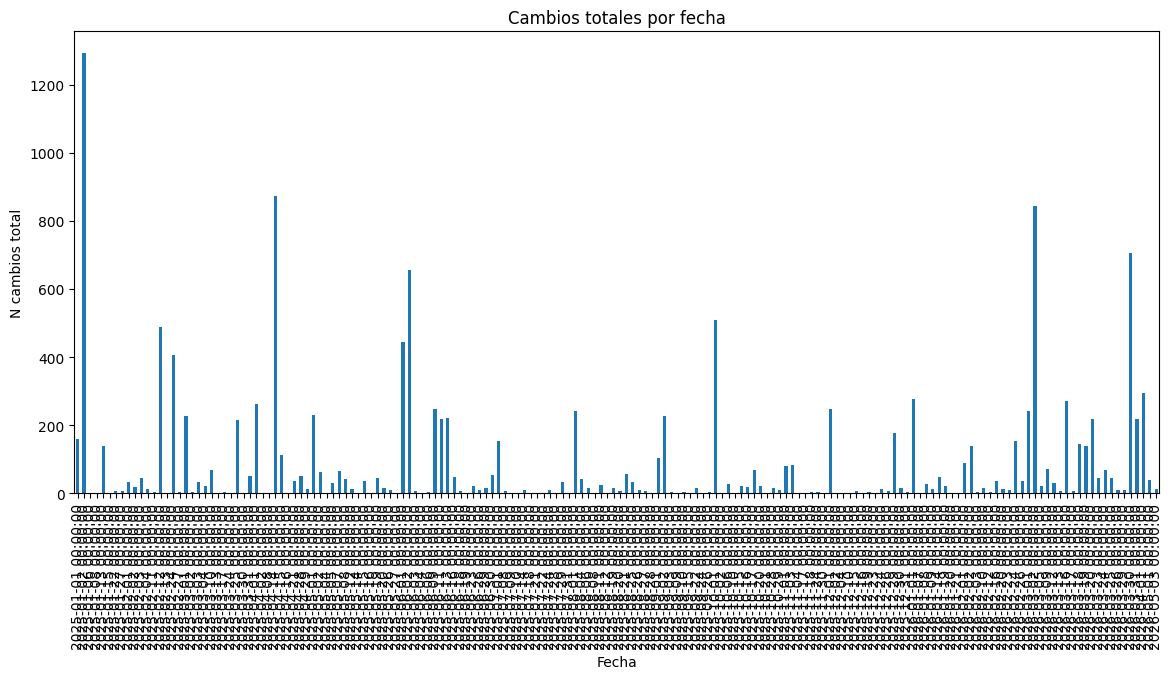

In [28]:
ax = tabla_cambios_por_fecha.plot(
    x="fecha",
    y="n_cambios_total",
    kind="bar",
    figsize=(14, 6),
    legend=False,
    title="Cambios totales por fecha"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("N cambios total")


In [29]:
# Agregar columna de descuento aplicado.
# Se considera que una venta calza con un descuento si el descuento porcentual observado
# queda dentro de una tolerancia chica respecto a uno de los descuentos disponibles.
# Prioridad global: carta_impacto -> base -> volumen_1 -> volumen_2 -> volumen_3 -> binario.
# Entre descuentos porcentuales se elige el de menor diferencia absoluta; ante empate,
# la comparación estricta diff < mejor_diff preserva el orden base -> volumen_1 -> volumen_2 -> volumen_3 -> binario.

tolerancia_pct = 1
eps_descuento = 1e-9
tolerancia_precio_carta = 1.0
labels_descuento = np.array([
    "ninguno",
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
], dtype=object)

# Descuento porcentual observado a nivel de precio por unidad.
descuento_pct_observado = ((ventas["precio_por_unidad"] / ventas["precio_lista_por_unidad"]) - 1.0).to_numpy(dtype=np.float32) * np.float32(100.0)

# Se guarda sólo el mejor match para no materializar matrices grandes en memoria.
mejor_diff = np.full(len(ventas), np.inf, dtype=np.float32)
codigos_descuento = np.zeros(len(ventas), dtype=np.int8)
descuento_pct_matcheado = np.zeros(len(ventas), dtype=np.float32)

def _actualizar_mejor_match(candidatos, codigo):
    candidatos = pd.to_numeric(candidatos, errors="coerce").to_numpy(dtype=np.float32)
    validos = (~np.isnan(candidatos)) & (np.abs(candidatos) > eps_descuento)
    if not validos.any():
        return

    diff = np.abs(descuento_pct_observado - candidatos)
    mask = validos & (diff <= tolerancia_pct) & (diff < mejor_diff)
    mejor_diff[mask] = diff[mask]
    codigos_descuento[mask] = codigo
    descuento_pct_matcheado[mask] = candidatos[mask]

_actualizar_mejor_match(ventas["dscto_base"], 1)

# dscto_volumen viene serializado como string tipo "[-5.0, -10.0]" en el CSV final.
mask_volumen = ventas["dscto_volumen"].notna()
if mask_volumen.any():
    volumen_extraido = ventas.loc[mask_volumen, "dscto_volumen"].astype("string").str.extract(
        r"\[\s*([-\d\.]+)?(?:,\s*([-\d\.]+))?(?:,\s*([-\d\.]+))?\s*\]"
    )
    idx_volumen = np.flatnonzero(mask_volumen.to_numpy())

    for codigo, col in enumerate(volumen_extraido.columns, start=2):
        candidatos = pd.to_numeric(volumen_extraido[col], errors="coerce").to_numpy(dtype=np.float32)
        validos = (~np.isnan(candidatos)) & (np.abs(candidatos) > eps_descuento)
        if not validos.any():
            continue

        diff = np.abs(descuento_pct_observado[idx_volumen] - candidatos)
        mejor_diff_local = mejor_diff[idx_volumen]
        mask = validos & (diff <= tolerancia_pct) & (diff < mejor_diff_local)
        if mask.any():
            idx_target = idx_volumen[mask]
            mejor_diff[idx_target] = diff[mask]
            codigos_descuento[idx_target] = codigo
            descuento_pct_matcheado[idx_target] = candidatos[mask]

_actualizar_mejor_match(ventas["dscto_binario"], 5)

# carta_impacto representa un precio objetivo, no un descuento porcentual, y si calza por precio_real
# dentro de la tolerancia definida, pisa cualquier match porcentual previo.
precio_real_array = pd.to_numeric(ventas["precio_real"], errors="coerce").to_numpy(dtype=np.float32)
precio_lista_array = pd.to_numeric(ventas["precio_lista"], errors="coerce").to_numpy(dtype=np.float32)
carta_array = pd.to_numeric(ventas["carta_impacto"], errors="coerce").to_numpy(dtype=np.float32)
carta_pct_equivalente = np.where(
    (~np.isnan(carta_array)) & (~np.isnan(precio_lista_array)) & (np.abs(precio_lista_array) > eps_descuento),
    ((carta_array / precio_lista_array) - np.float32(1.0)) * np.float32(100.0),
    np.nan,
)
mask_carta = (~np.isnan(carta_array)) & (np.abs(precio_real_array - carta_array) <= tolerancia_precio_carta)
codigos_descuento[mask_carta] = 6
descuento_pct_matcheado[mask_carta] = carta_pct_equivalente[mask_carta]
mejor_diff[mask_carta] = np.abs(descuento_pct_observado[mask_carta] - descuento_pct_matcheado[mask_carta])

ventas["descuento_pct_observado"] = descuento_pct_observado
ventas["descuento_pct_matcheado"] = descuento_pct_matcheado
ventas["diferencia_descuento_pct"] = ventas["descuento_pct_observado"] - ventas["descuento_pct_matcheado"]
ventas["descuento_aplicado"] = pd.Categorical.from_codes(codigos_descuento, categories=labels_descuento)
ventas["calza_con_descuento"] = np.not_equal(codigos_descuento, 0)

print("Distribución descuento_aplicado:")
print(ventas["descuento_aplicado"].value_counts(dropna=False))
print(f"Cobertura de match: {ventas['calza_con_descuento'].mean():.2%}")

cols_muestra = [
    "cod_sku",
    "cod_canal_comercial",
    "cod_consolidado",
    "fecha_factura",
    "precio_por_unidad",
    "precio_lista_por_unidad",
    "descuento_pct_observado",
    "dscto_base",
    "dscto_volumen",
    "dscto_binario",
    "carta_impacto",
    "descuento_pct_matcheado",
    "diferencia_descuento_pct",
    "descuento_aplicado",
]
ventas.loc[ventas["calza_con_descuento"], cols_muestra].head()

Distribución descuento_aplicado:
descuento_aplicado
ninguno          7240132
binario          1151277
base              918368
volumen_1         214383
volumen_2          82676
volumen_3          29549
carta_impacto       2091
Name: count, dtype: int64
Cobertura de match: 24.88%


,cod_sku,cod_canal_comercial,cod_consolidado,fecha_factura,precio_por_unidad,precio_lista_por_unidad,descuento_pct_observado,dscto_base,dscto_volumen,dscto_binario,carta_impacto,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado
4,8451,MY,57,2025-01-02,2308.625000,2456.0,-6.000611,-6.0,NaN,NaN,NaN,-6.0,-0.000611,base
5,8454,MY,57,2025-01-02,2066.118750,2198.0,-6.000057,-6.0,NaN,NaN,NaN,-6.0,-0.000057,base
8,3003,CB,54,2025-01-02,20275.111111,20902.0,-2.999181,-3.0,NaN,NaN,NaN,-3.0,0.000819,base
11,1446,MY,67,2025-01-03,2187.200000,2585.6,-15.408416,-15.4,NaN,NaN,NaN,-15.4,-0.008416,base
13,8453,MY,57,2025-01-02,2066.125000,2198.0,-5.999773,-6.0,NaN,NaN,NaN,-6.0,0.000227,base


In [30]:
ventas.loc[~ventas["calza_con_descuento"], cols_muestra].head()

,cod_sku,cod_canal_comercial,cod_consolidado,fecha_factura,precio_por_unidad,precio_lista_por_unidad,descuento_pct_observado,dscto_base,dscto_volumen,dscto_binario,carta_impacto,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado
0,3034,CB,32,2025-01-02,1086.000000,1153.80,-5.876235,NaN,NaN,NaN,NaN,0.0,-5.876235,ninguno
1,3288,CB,32,2025-01-02,1968.300000,2036.34,-3.341289,NaN,NaN,NaN,NaN,0.0,-3.341289,ninguno
2,3095,MY,38,2025-01-02,4013.000000,4395.50,-8.702082,-3.0,NaN,NaN,NaN,0.0,-8.702082,ninguno
3,8043,CB,32,2025-01-02,10860.000000,11247.00,-3.440918,NaN,NaN,NaN,NaN,0.0,-3.440918,ninguno
6,3239,CB,54,2025-01-02,19749.031297,21990.00,-10.190853,-3.0,NaN,NaN,NaN,0.0,-10.190853,ninguno


In [31]:
# gap/no-gap
ventas['gap'] = ventas['diferencia_descuento_pct'].abs() > 1

In [32]:
ventas["gap"].value_counts()

gap
False    8943413
True      695063
Name: count, dtype: int64

In [33]:
# Graficar monto total real correspondiente a gap por cada mes año, grafico de barras
ventas_gap = ventas[ventas["gap"]==True]

ventas_gap_por_mes = ventas_gap.groupby(["año_factura", "mes_factura"]).agg(
    monto_real=pd.NamedAgg(column="monto_real", aggfunc="sum")
).reset_index()

ventas_gap_por_mes

,año_factura,mes_factura,monto_real
0,2025,1,1762579812
1,2025,2,1408499318
2,2025,3,1358103779
3,2025,4,1341459103
4,2025,5,1509561372
5,2025,6,1366194371
6,2025,7,1455708153
7,2025,8,1229188061
8,2025,9,1129438889
9,2025,11,1033096958


In [34]:
ventas_gap["distrito"].value_counts()

distrito
SAN FERNANDO               37964
SANTIAGO CENTRO COSTA      37706
RANCAGUA                   33658
SANTIAGO NORTE 1           31218
CHILLAN                    29181
SANTIAGO SUR 2             27950
CONCEPCION SUR             27754
TEMUCO SUR                 26805
LA SERENA                  25467
SANTIAGO PONIENTE 2        24897
VIÑA INTERIOR              24284
TEMUCO NORTE               23979
SANTIAGO SUR 1             23699
VIÑA COSTA                 22146
SANTIAGO PONIENTE 1        21757
LOS ANGELES                21272
SANTIAGO NORTE 2           20276
OSORNO                     18864
SANTIAGO CENTRO ORIENTE    17225
SAN FELIPE                 16919
TALCA                      16902
ANTOFAGASTA                16671
CURICO                     15762
OVALLE                     14992
PUNTA ARENAS               12905
SANTIAGO MAYORISTA         11822
IQUIQUE                    10344
ARICA                       9491
CALAMA                      7687
CONCEPCION NORTE            7550
C

In [35]:
ventas_gap.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,cantidad_unidades_entera,inconsistencia,precio_por_unidad,precio_lista_por_unidad,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,calza_con_descuento,gap
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.000,...,True,False,1086.000000,1153.80,-5.876235,0.0,-5.876235,ninguno,False,True
1,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.600,...,True,False,1968.300000,2036.34,-3.341289,0.0,-3.341289,ninguno,False,True
2,1173743,MY,38,NORTE 2,LA SERENA,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.000,...,True,False,4013.000000,4395.50,-8.702082,0.0,-8.702082,ninguno,False,True
3,1003766,CB,32,NORTE 2,LA SERENA,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.000,...,True,False,10860.000000,11247.00,-3.440918,0.0,-3.440918,ninguno,False,True
6,1072277,CB,54,SUR 3,PUNTA ARENAS,2025-01-02,3239,JAMON CENTENARIO COLONIAL MINI PZA LP,22086,3.355,...,False,False,19749.031297,21990.00,-10.190853,0.0,-10.190853,ninguno,False,True


In [36]:
ventas_gap_por_fecha_factura = ventas_gap.groupby(["fecha_factura"]).agg(
    n_facturas=pd.NamedAgg(column="monto_real", aggfunc="count")
).reset_index().sort_values("n_facturas", ascending=False)

ventas_gap_por_fecha_factura.head(n=20)

,fecha_factura,n_facturas
0,2025-01-02,9330
37,2025-02-12,5059
362,2026-02-24,4732
356,2026-02-17,3924
342,2026-02-03,3812
349,2026-02-10,3669
357,2026-02-18,3609
113,2025-05-06,3582
30,2025-02-04,3553
358,2026-02-19,3537


In [37]:
ventas_no_gap = ventas[ventas["gap"]==False]
ventas_no_gap["descuento_aplicado"].value_counts()

descuento_aplicado
ninguno          6545069
binario          1151277
base              918368
volumen_1         214383
volumen_2          82676
volumen_3          29549
carta_impacto       2091
Name: count, dtype: int64

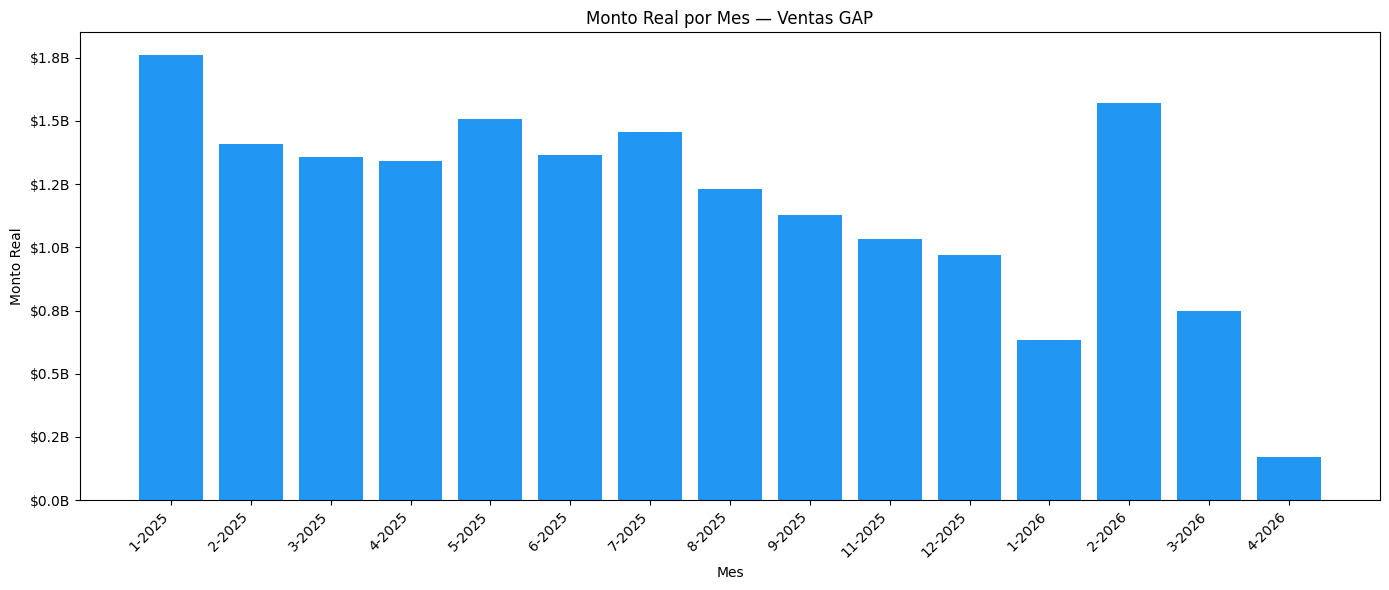

In [38]:
import matplotlib.ticker as mticker

# Crear etiqueta de mes-año para el eje X
ventas_gap_por_mes['periodo'] = ventas_gap_por_mes['mes_factura'].astype(str) + '-' + ventas_gap_por_mes['año_factura'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(ventas_gap_por_mes['periodo'], ventas_gap_por_mes['monto_real'], color='#2196F3')

# Formato eje Y en miles de millones
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))
ax.set_xlabel('Mes')
ax.set_ylabel('Monto Real')
ax.set_title('Monto Real por Mes — Ventas GAP')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [39]:
# Calcular el "costo" de cada descuento como la diferencia entre el precio lista y el precio real, multiplicado por la cantidad en unidades vendida.
# Esto sólo para las ventas que calzan con algún descuento, para evitar ruido de errores de medición o casos atípicos sin descuento claro.
ventas["monto_a_precio_lista"] = ventas["precio_lista"] * ventas["kilo_real"]
ventas["costo_descuento"] = ventas["monto_a_precio_lista"] - ventas["monto_real"] #(ventas["precio_lista_por_unidad"] - ventas["precio_por_unidad"]) * ventas["cantidad_unidades"]
#ventas["costo_descuento"] = ventas["costo_descuento"].where(ventas["calza_con_descuento"], 0.0)
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,precio_por_unidad,precio_lista_por_unidad,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,...,1086.000,1153.80,-5.876235,0.0,-5.876235,ninguno,False,True,46152.0,2712.0
1,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3288,TOCINO CORTADO 10x180 GR LP,39366,3.6,...,1968.300,2036.34,-3.341289,0.0,-3.341289,ninguno,False,True,40726.8,1360.8
2,1173743,MY,38,NORTE 2,LA SERENA,2025-01-02,3095,TOCINO HORECA 4x500 R LP,321040,40.0,...,4013.000,4395.50,-8.702082,0.0,-8.702082,ninguno,False,True,351640.0,30600.0
3,1003766,CB,32,NORTE 2,LA SERENA,2025-01-02,8043,BOLOGNA 3 KGS.WIN,10860,3.0,...,10860.000,11247.00,-3.440918,0.0,-3.440918,ninguno,False,True,11247.0,387.0
4,1037307,MY,57,SUR 2,CHILLAN,2025-01-02,8451,SALCHICHA SUREÑA WINTER 1 KG,36938,16.0,...,2308.625,2456.00,-6.000611,-6.0,-0.000611,base,True,False,39296.0,2358.0


In [40]:
# COMPLETAR: Para aquuelas ventas donde gap sea true y al redondear
mask_base_forzado =  (ventas["gap"]==True) & (ventas["descuento_pct_observado"].round().isin([-3.0, -6.0]))
mask_liq_forzado = (ventas["gap"]==True) & (ventas["descuento_pct_observado"].round().le(-40.0))

ventas['descuento_aplicado'] = ventas['descuento_aplicado'].cat.add_categories(["base_forzado", "liquidacion_forzado"])
ventas.loc[mask_base_forzado, "descuento_aplicado"] = "base_forzado"
ventas.loc[mask_liq_forzado, "descuento_aplicado"] = "liquidacion_forzado"

In [41]:
mask_base_forzado.value_counts()

False    9080819
True      557657
Name: count, dtype: int64

In [42]:
print(ventas[ventas["descuento_aplicado"]=="base_forzado"]["costo_descuento"].sum())
print(ventas[ventas["descuento_aplicado"]=="liquidacion_forzado"]["costo_descuento"].sum())

382281715.714
3084443772.2130003


In [43]:
# Armar tabla con monto total vendido y costo por tipo de descuento y graficar como barras.
tabla_descuentos = ventas.groupby("descuento_aplicado").agg(
    monto_a_precio_lista=pd.NamedAgg(column="monto_a_precio_lista", aggfunc="sum"),
    monto_total_vendido=pd.NamedAgg(column="monto_real", aggfunc="sum"),
    costo_total_descuento=pd.NamedAgg(column="costo_descuento", aggfunc="sum")
).reset_index()
tabla_descuentos["costo_total_dscto_v2"] = tabla_descuentos["monto_a_precio_lista"] - tabla_descuentos["monto_total_vendido"]
print(tabla_descuentos)

    descuento_aplicado  monto_a_precio_lista  monto_total_vendido  \
0              ninguno          1.099861e+11         109571532947   
1                 base          3.882778e+10          36904908206   
2            volumen_1          5.635991e+09           5070172062   
3            volumen_2          3.754989e+09           3209487327   
4            volumen_3          1.963495e+09           1568828912   
5              binario          2.862768e+10          24634153815   
6        carta_impacto          1.689803e+08            147311728   
7         base_forzado          1.251561e+10          12133325102   
8  liquidacion_forzado          5.656272e+09           2571828370   

   costo_total_descuento  costo_total_dscto_v2  
0           4.145670e+08          4.145670e+08  
1           1.922871e+09          1.922871e+09  
2           5.658186e+08          5.658186e+08  
3           5.455016e+08          5.455016e+08  
4           3.946665e+08          3.946665e+08  
5           3.9

In [44]:
# Quiero un gráfico de barras con una columna que tenga el monto total si todo se vendía a precio lista y luego una columna por tipo de descuento indicando el costo de ese descuento para finalmente llegar a una columan con el monto real vendido.
monto_a_precio_lista = ventas["monto_a_precio_lista"].sum()
costo_dscto_base = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "base", "costo_total_descuento"].values[0]
costo_dscto_volumen_1 = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "volumen_1", "costo_total_descuento"].values[0]
costo_dscto_volumen_2 = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "volumen_2", "costo_total_descuento"].values[0]
costo_dscto_volumen_3 = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "volumen_3", "costo_total_descuento"].values[0]
costo_dscto_binario = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "binario", "costo_total_descuento"].values[0]
costo_dscto_carta = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "carta_impacto", "costo_total_descuento"].values[0]
costo_dscto_base_forzado = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "base_forzado", "costo_total_descuento"].values[0]
costo_dscto_liquidacion_forzado = tabla_descuentos.loc[tabla_descuentos["descuento_aplicado"] == "liquidacion_forzado", "costo_total_descuento"].values[0]
monto_real = ventas["monto_real"].sum()
error = monto_a_precio_lista - (costo_dscto_base + costo_dscto_volumen_1 + costo_dscto_volumen_2 + costo_dscto_volumen_3 + costo_dscto_binario + costo_dscto_carta + costo_dscto_base_forzado+ costo_dscto_liquidacion_forzado + monto_real)

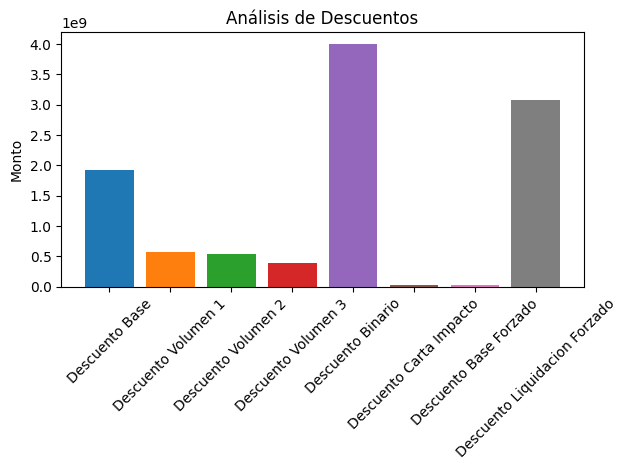

In [45]:


# Graficamos una barra por cada uno de los numeros de arriba
plt.Figure(figsize=(10, 6))
#plt.bar("Monto a Precio Lista", monto_a_precio_lista, label="Precio Lista")
plt.bar("Descuento Base", costo_dscto_base, label="Descuento Base")
plt.bar("Descuento Volumen 1", costo_dscto_volumen_1, label="Descuento Volumen 1")
plt.bar("Descuento Volumen 2", costo_dscto_volumen_2, label="Descuento Volumen 2")
plt.bar("Descuento Volumen 3", costo_dscto_volumen_3, label="Descuento Volumen 3")
plt.bar("Descuento Binario", costo_dscto_binario, label="Descuento Binario")
plt.bar("Descuento Carta Impacto", costo_dscto_carta, label="Descuento Carta Impacto")
plt.bar("Descuento Base Forzado", costo_dscto_carta, label="Descuento Base Forzado")
plt.bar("Descuento Liquidacion Forzado", costo_dscto_liquidacion_forzado, label="Descuento Liquidacion Forzado")
#plt.bar("Monto Real", monto_real, label="Monto Real")
#plt.bar("Error", error, label="Error", color="red")
plt.ylabel("Monto")
plt.title("Análisis de Descuentos")
#plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

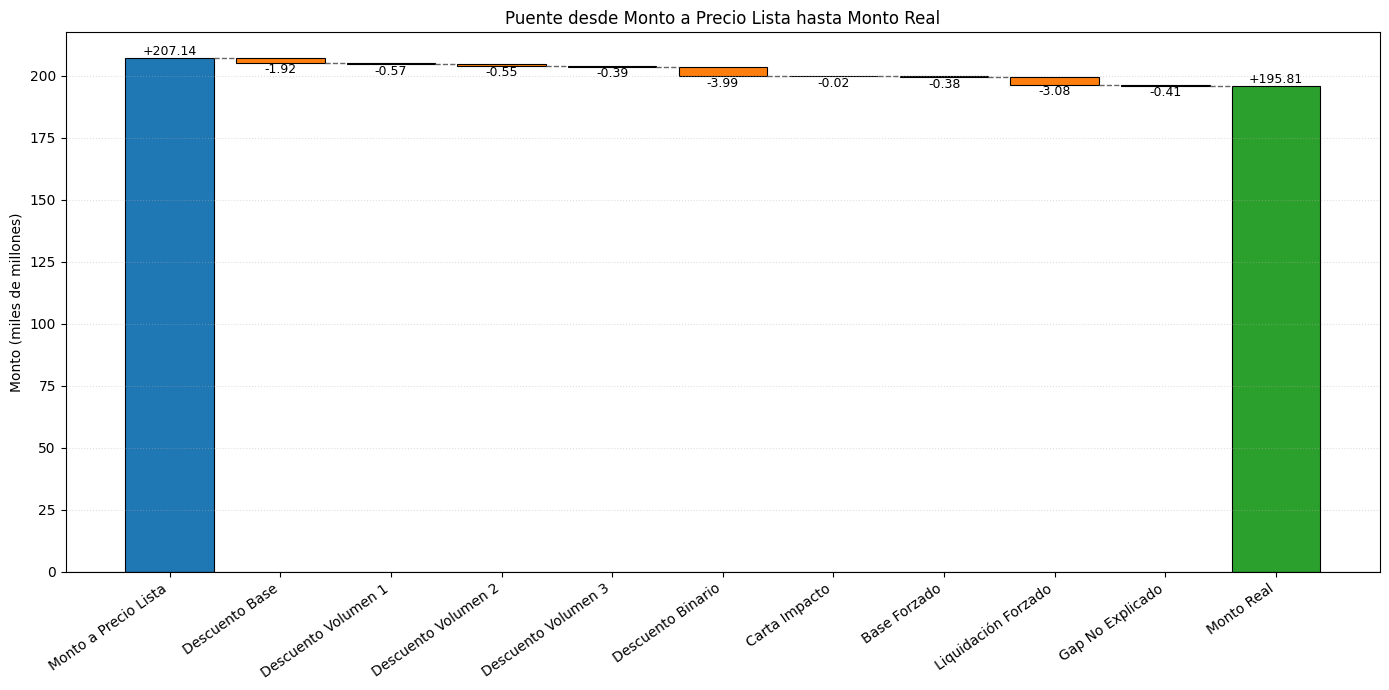

,concepto,valor
0,Monto a Precio Lista,2.071369e+11
1,Descuentos Explicados,1.091078e+10
2,Gap No Explicado,4.145670e+08
3,Monto Real,1.958115e+11
4,% gap explicado,9.633948e-01


,etapa,valor,tipo
0,Monto a Precio Lista,2.071369e+11,total
1,Descuento Base,-1.922871e+09,change
2,Descuento Volumen 1,-5.658186e+08,change
3,Descuento Volumen 2,-5.455016e+08,change
4,Descuento Volumen 3,-3.946665e+08,change
5,Descuento Binario,-3.993527e+09,change
6,Carta Impacto,-2.166856e+07,change
7,Base Forzado,-3.822817e+08,change
8,Liquidación Forzado,-3.084444e+09,change
9,Gap No Explicado,-4.145670e+08,change


In [46]:
# Gráfico tipo cascada: desde monto a precio lista hasta monto real.
# Los descuentos explicados se restan como variaciones negativas y el residuo queda en Gap No Explicado.

categorias_descuento = ["base", "volumen_1", "volumen_2", "volumen_3", "binario", "carta_impacto", "base_forzado", "liquidacion_forzado"]
labels_descuento = {
    "base": "Descuento Base",
    "volumen_1": "Descuento Volumen 1",
    "volumen_2": "Descuento Volumen 2",
    "volumen_3": "Descuento Volumen 3",
    "binario": "Descuento Binario",
    "carta_impacto": "Carta Impacto",
    "base_forzado": "Base Forzado",
    "liquidacion_forzado": "Liquidación Forzado",
}

costos_explicados = (
    tabla_descuentos
    .set_index("descuento_aplicado")["costo_total_descuento"]
    .reindex(categorias_descuento, fill_value=0.0)
)

monto_a_precio_lista_total = ventas["monto_a_precio_lista"].sum()
monto_real_total = ventas["monto_real"].sum()
gap_total = monto_a_precio_lista_total - monto_real_total
descuentos_explicados_total = costos_explicados.sum()
gap_no_explicado = gap_total - descuentos_explicados_total

waterfall_steps = [("Monto a Precio Lista", monto_a_precio_lista_total, "total")]
waterfall_steps.extend((labels_descuento[c], -costos_explicados[c], "change") for c in categorias_descuento)
waterfall_steps.append(("Gap No Explicado", -gap_no_explicado, "change"))
waterfall_steps.append(("Monto Real", monto_real_total, "total"))

waterfall_df = pd.DataFrame(waterfall_steps, columns=["etapa", "valor", "tipo"])
waterfall_df["running_after"] = np.nan
waterfall_df["bottom"] = 0.0
waterfall_df["height"] = 0.0

running = 0.0
for i, row in waterfall_df.iterrows():
    valor = row["valor"]
    if row["tipo"] == "total":
        waterfall_df.at[i, "bottom"] = 0.0
        waterfall_df.at[i, "height"] = valor
        running = valor
    else:
        next_running = running + valor
        waterfall_df.at[i, "bottom"] = min(running, next_running)
        waterfall_df.at[i, "height"] = abs(valor)
        running = next_running
    waterfall_df.at[i, "running_after"] = running

escala = 1e9
waterfall_df["bottom_plot"] = waterfall_df["bottom"] / escala
waterfall_df["height_plot"] = waterfall_df["height"] / escala
waterfall_df["valor_plot"] = waterfall_df["valor"] / escala
waterfall_df["running_plot"] = waterfall_df["running_after"] / escala

colors = []
for _, row in waterfall_df.iterrows():
    if row["tipo"] == "total":
        colors.append("#1f77b4" if row["etapa"] == "Monto a Precio Lista" else "#2ca02c")
    elif row["etapa"] == "Gap No Explicado":
        colors.append("#d62728" if row["valor"] < 0 else "#ff9896")
    else:
        colors.append("#ff7f0e")

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(waterfall_df))
ax.bar(x, waterfall_df["height_plot"], bottom=waterfall_df["bottom_plot"], color=colors, edgecolor="black", linewidth=0.8)

# Líneas conectoras entre pasos para reforzar el efecto cascada.
for i in range(len(waterfall_df) - 1):
    y = waterfall_df.loc[i, "running_plot"]
    ax.plot([x[i] + 0.4, x[i + 1] - 0.4], [y, y], color="#666666", linestyle="--", linewidth=1)

for i, row in waterfall_df.iterrows():
    if row["tipo"] == "total":
        y_text = row["height_plot"]
    else:
        y_text = row["running_plot"]
    va = "bottom" if row["valor"] >= 0 else "top"
    offset = 0.15 if row["valor"] >= 0 else -0.15
    ax.text(
        x[i],
        y_text + offset,
        f"{row['valor_plot']:+.2f}",
        ha="center",
        va=va,
        fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(waterfall_df["etapa"], rotation=35, ha="right")
ax.set_ylabel("Monto (miles de millones)")
ax.set_title("Puente desde Monto a Precio Lista hasta Monto Real")
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

resumen_waterfall = pd.DataFrame({
    "concepto": [
        "Monto a Precio Lista",
        "Descuentos Explicados",
        "Gap No Explicado",
        "Monto Real",
        "% gap explicado",
    ],
    "valor": [
        monto_a_precio_lista_total,
        descuentos_explicados_total,
        gap_no_explicado,
        monto_real_total,
        np.nan if gap_total == 0 else descuentos_explicados_total / gap_total,
    ]
})
display(resumen_waterfall)
display(waterfall_df[["etapa", "valor", "tipo"]])


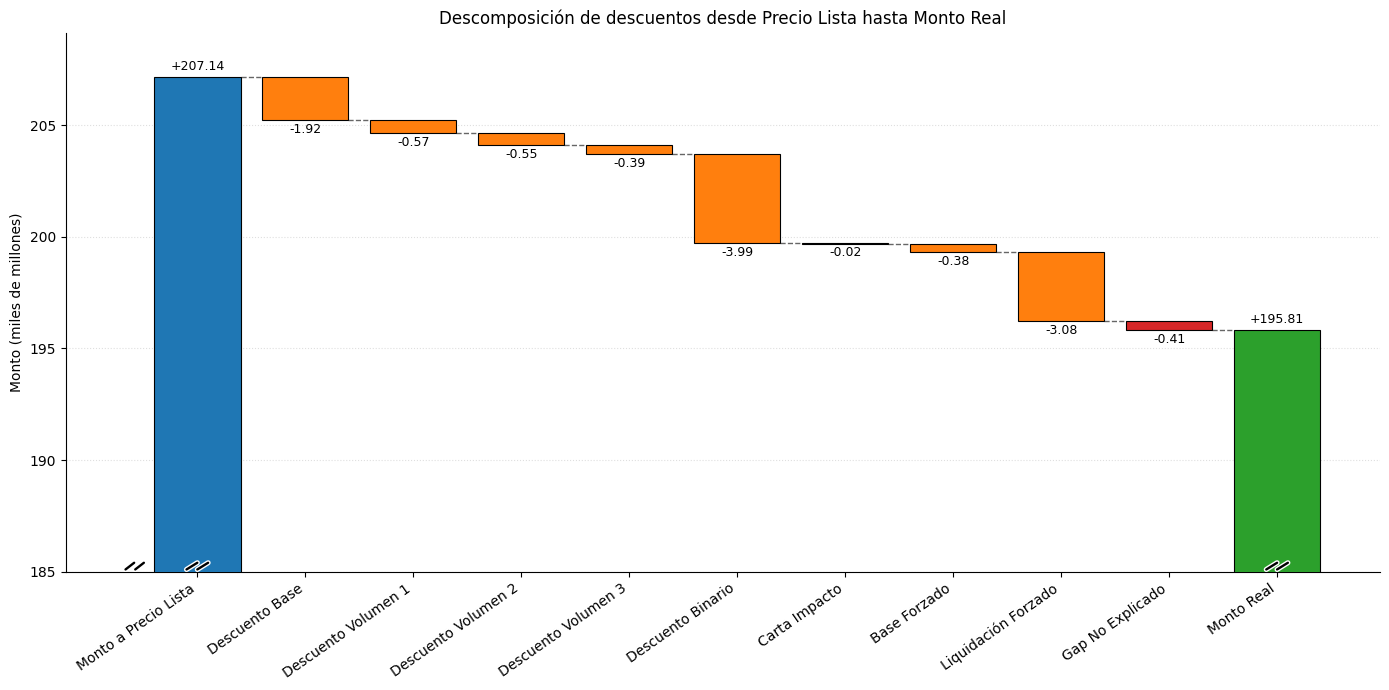

,concepto,valor
0,Monto a Precio Lista,2.071369e+11
1,Descuentos Explicados,1.091078e+10
2,Gap No Explicado,4.145670e+08
3,Monto Real,1.958115e+11
4,% gap explicado,9.633948e-01


,etapa,valor,tipo
0,Monto a Precio Lista,2.071369e+11,total
1,Descuento Base,-1.922871e+09,change
2,Descuento Volumen 1,-5.658186e+08,change
3,Descuento Volumen 2,-5.455016e+08,change
4,Descuento Volumen 3,-3.946665e+08,change
5,Descuento Binario,-3.993527e+09,change
6,Carta Impacto,-2.166856e+07,change
7,Base Forzado,-3.822817e+08,change
8,Liquidación Forzado,-3.084444e+09,change
9,Gap No Explicado,-4.145670e+08,change


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# =========================
# CONFIGURACIÓN
# =========================
# Ajusta este valor para definir desde dónde parte visualmente el eje Y.
# Mientras más alto, más "zoom" sobre los descuentos.
Y_FLOOR = 185

# Si quieres que sea automático, puedes poner:
# Y_FLOOR = None


# =========================
# DATOS BASE
# =========================
categorias_descuento = [
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
    "base_forzado",
    "liquidacion_forzado"
]

labels_descuento = {
    "base": "Descuento Base",
    "volumen_1": "Descuento Volumen 1",
    "volumen_2": "Descuento Volumen 2",
    "volumen_3": "Descuento Volumen 3",
    "binario": "Descuento Binario",
    "carta_impacto": "Carta Impacto",
    "base_forzado": "Base Forzado",
    "liquidacion_forzado": "Liquidación Forzado"
}

costos_explicados = (
    tabla_descuentos
    .set_index("descuento_aplicado")["costo_total_descuento"]
    .reindex(categorias_descuento, fill_value=0.0)
)

monto_a_precio_lista_total = ventas["monto_a_precio_lista"].sum()
monto_real_total = ventas["monto_real"].sum()
gap_total = monto_a_precio_lista_total - monto_real_total
descuentos_explicados_total = costos_explicados.sum()
gap_no_explicado = gap_total - descuentos_explicados_total

waterfall_steps = [("Monto a Precio Lista", monto_a_precio_lista_total, "total")]
waterfall_steps.extend(
    (labels_descuento[c], -costos_explicados[c], "change")
    for c in categorias_descuento
)
waterfall_steps.append(("Gap No Explicado", -gap_no_explicado, "change"))
waterfall_steps.append(("Monto Real", monto_real_total, "total"))

waterfall_df = pd.DataFrame(waterfall_steps, columns=["etapa", "valor", "tipo"])
waterfall_df["running_after"] = np.nan
waterfall_df["bottom"] = 0.0
waterfall_df["height"] = 0.0

running = 0.0
for i, row in waterfall_df.iterrows():
    valor = row["valor"]

    if row["tipo"] == "total":
        waterfall_df.at[i, "bottom"] = 0.0
        waterfall_df.at[i, "height"] = valor
        running = valor
    else:
        next_running = running + valor
        waterfall_df.at[i, "bottom"] = min(running, next_running)
        waterfall_df.at[i, "height"] = abs(valor)
        running = next_running

    waterfall_df.at[i, "running_after"] = running

escala = 1e9
waterfall_df["bottom_plot"] = waterfall_df["bottom"] / escala
waterfall_df["height_plot"] = waterfall_df["height"] / escala
waterfall_df["valor_plot"] = waterfall_df["valor"] / escala
waterfall_df["running_plot"] = waterfall_df["running_after"] / escala
waterfall_df["top_plot"] = waterfall_df["bottom_plot"] + waterfall_df["height_plot"]

# Colores
colors = []
for _, row in waterfall_df.iterrows():
    if row["tipo"] == "total":
        colors.append("#1f77b4" if row["etapa"] == "Monto a Precio Lista" else "#2ca02c")
    elif row["etapa"] == "Gap No Explicado":
        colors.append("#d62728" if row["valor"] < 0 else "#ff9896")
    else:
        colors.append("#ff7f0e")


# =========================
# FUNCIONES AUXILIARES
# =========================
def add_break_marker(ax, patch, y_break, dx=0.10, dy=0.30, gap=0.10, lw=1.7):
    """
    Dibuja el símbolo // sobre una barra truncada visualmente.
    """
    xc = patch.get_x() + patch.get_width() / 2

    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [xc + shift - dx / 2, xc + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=8
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


def add_axis_break(ax, y_break, x_offset=-0.58, dx=0.08, dy=0.30, gap=0.09, lw=1.7):
    """
    Dibuja // sobre el eje Y izquierdo para reforzar la idea de recorte.
    """
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [x_offset + shift - dx / 2, x_offset + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=9
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


# =========================
# GRÁFICO
# =========================
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(waterfall_df))
bar_width = 0.8

bars = ax.bar(
    x,
    waterfall_df["height_plot"],
    bottom=waterfall_df["bottom_plot"],
    width=bar_width,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

# Líneas conectoras entre pasos
for i in range(len(waterfall_df) - 1):
    y = waterfall_df.loc[i, "running_plot"]
    ax.plot(
        [x[i] + bar_width / 2, x[i + 1] - bar_width / 2],
        [y, y],
        color="#666666",
        linestyle="--",
        linewidth=1,
        zorder=2
    )

# =========================
# RANGO VISUAL (RECORTE TIPO THINK-CELL)
# =========================
if Y_FLOOR is None:
    running_max = max(
        waterfall_df["running_plot"].max(),
        waterfall_df["height_plot"].max()
    )
    running_min = min(
        waterfall_df["running_plot"].min(),
        waterfall_df.loc[waterfall_df["tipo"] == "change", "bottom_plot"].min(),
        waterfall_df["height_plot"].iloc[-1]
    )
    span = running_max - running_min
    y_floor = running_min - max(span * 0.12, 0.8)
else:
    y_floor = Y_FLOOR

visible_max = max(
    waterfall_df["top_plot"].max(),
    waterfall_df["running_plot"].max()
)
y_top = visible_max + 2.0

ax.set_ylim(y_floor, y_top)

# Marcar barras truncadas con //
for patch, (_, row) in zip(bars, waterfall_df.iterrows()):
    cruza_recorte = (row["bottom_plot"] < y_floor) and (row["top_plot"] > y_floor)
    if cruza_recorte:
        add_break_marker(ax, patch, y_floor + 0.25)

# Marcar también el eje Y
add_axis_break(ax, y_floor + 0.25)

# =========================
# ETIQUETAS
# =========================
for i, row in waterfall_df.iterrows():
    valor_txt = f"{row['valor_plot']:+.2f}"

    if row["tipo"] == "total":
        y_text = row["top_plot"] + 0.18
        va = "bottom"
    else:
        if row["valor"] < 0:
            y_text = row["running_plot"] - 0.12
            va = "top"
        else:
            y_text = row["running_plot"] + 0.12
            va = "bottom"

    ax.text(
        x[i],
        y_text,
        valor_txt,
        ha="center",
        va=va,
        fontsize=9,
        zorder=10
    )

# =========================
# FORMATO
# =========================
ax.set_xticks(x)
ax.set_xticklabels(waterfall_df["etapa"], rotation=35, ha="right")
ax.set_ylabel("Monto (miles de millones)")
ax.set_title("Descomposición de descuentos desde Precio Lista hasta Monto Real")

ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# =========================
# TABLAS DE APOYO
# =========================
resumen_waterfall = pd.DataFrame({
    "concepto": [
        "Monto a Precio Lista",
        "Descuentos Explicados",
        "Gap No Explicado",
        "Monto Real",
        "% gap explicado",
    ],
    "valor": [
        monto_a_precio_lista_total,
        descuentos_explicados_total,
        gap_no_explicado,
        monto_real_total,
        np.nan if gap_total == 0 else descuentos_explicados_total / gap_total,
    ]
})

display(resumen_waterfall)
display(waterfall_df[["etapa", "valor", "tipo"]])

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_41014/2160080421.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  datos_error_match["descuento_aplicado"] = pd.Categorical(


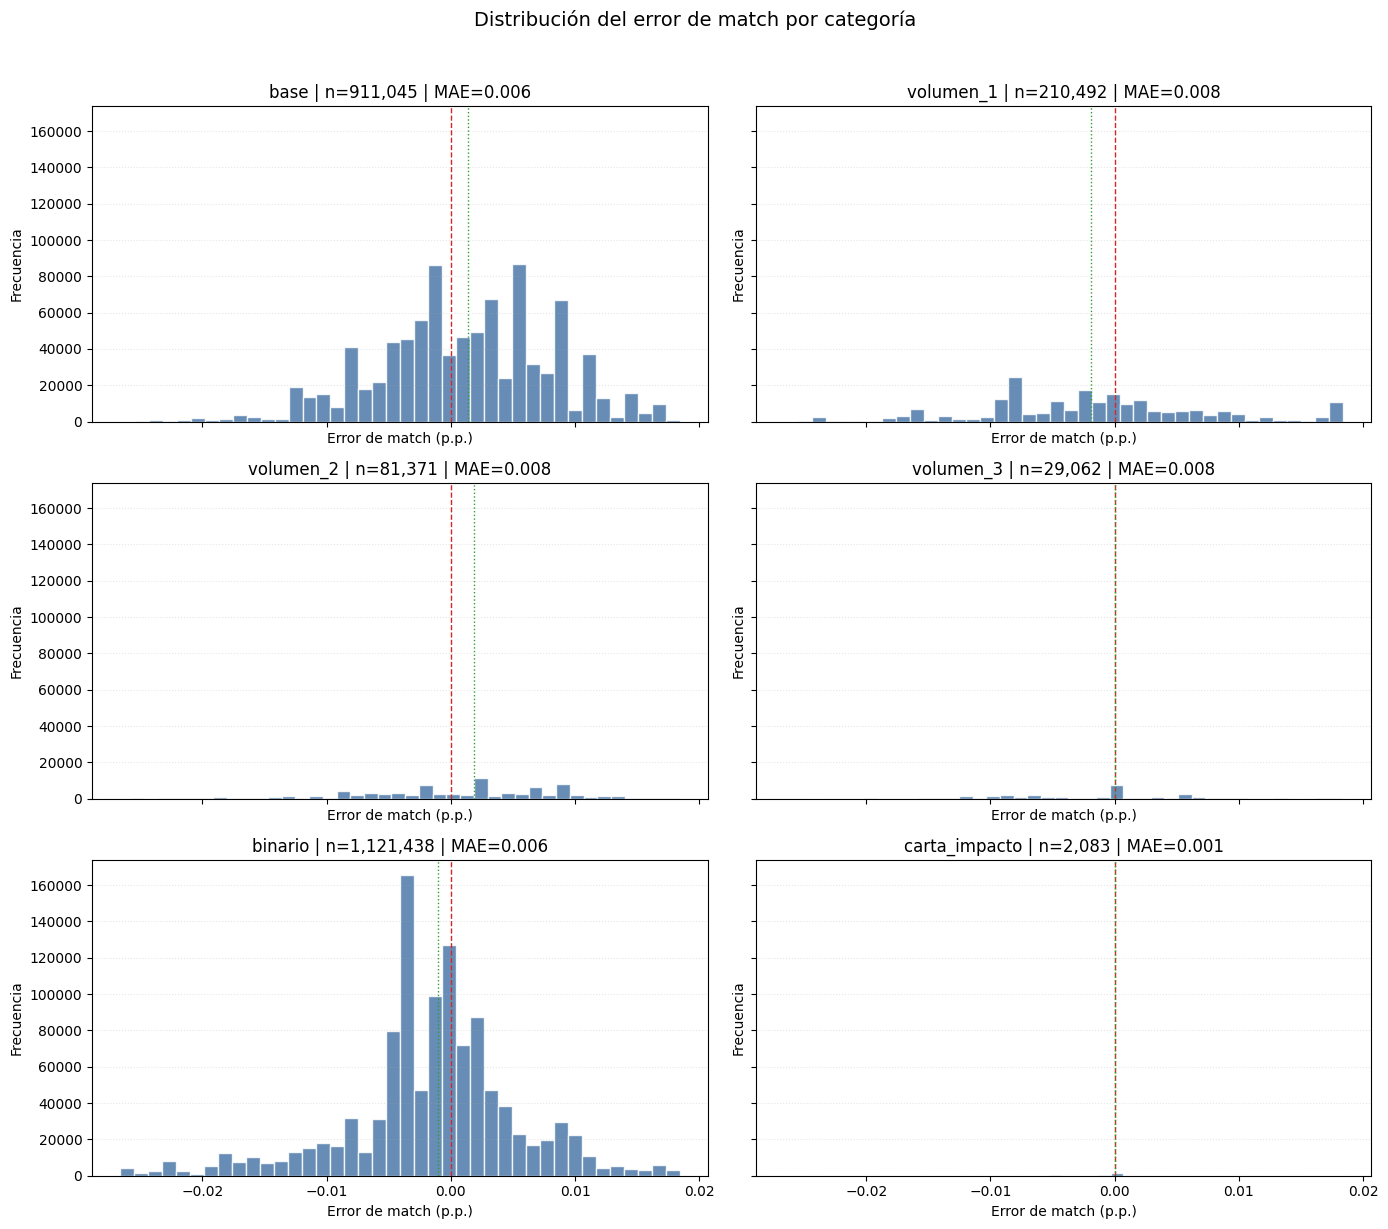

,descuento_aplicado,n,error_promedio,error_mediano,mae,p95_abs
0,base,918368,0.001182,0.001392,0.005933,0.014658
1,volumen_1,214383,-0.001614,-0.001920,0.007692,0.018416
2,volumen_2,82676,0.000178,0.001871,0.008241,0.016683
3,volumen_3,29549,-0.000181,0.000000,0.008000,0.015438
4,binario,1151277,-0.001837,-0.001000,0.005759,0.018333
5,carta_impacto,2091,-0.000365,-0.000002,0.001332,0.005226


In [48]:
# Error de match por categoría.
# Se grafica la diferencia entre descuento observado y descuento matcheado
# sólo para ventas que efectivamente calzaron con alguna categoría.

orden_categorias = ["base", "volumen_1", "volumen_2", "volumen_3", "binario", "carta_impacto"]

datos_error_match = ventas.loc[
    ventas["calza_con_descuento"],
    ["descuento_aplicado", "diferencia_descuento_pct"]
].copy()
datos_error_match["descuento_aplicado"] = pd.Categorical(
    datos_error_match["descuento_aplicado"],
    categories=orden_categorias,
    ordered=True,
)
datos_error_match = datos_error_match.dropna(subset=["diferencia_descuento_pct"])

categorias_presentes = [
    cat for cat in orden_categorias
    if (datos_error_match["descuento_aplicado"] == cat).any()
]

if not categorias_presentes:
    print("No hay ventas matcheadas para graficar error de match.")
else:
    q_low, q_high = datos_error_match["diferencia_descuento_pct"].quantile([0.01, 0.99])
    datos_error_plot = datos_error_match[
        datos_error_match["diferencia_descuento_pct"].between(q_low, q_high)
    ].copy()

    ncols = 2
    nrows = int(np.ceil(len(categorias_presentes) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, categoria in zip(axes, categorias_presentes):
        sub = datos_error_plot.loc[datos_error_plot["descuento_aplicado"] == categoria, "diferencia_descuento_pct"]
        mae = datos_error_match.loc[datos_error_match["descuento_aplicado"] == categoria, "diferencia_descuento_pct"].abs().mean()
        mediana = datos_error_match.loc[datos_error_match["descuento_aplicado"] == categoria, "diferencia_descuento_pct"].median()
        ax.hist(sub, bins=40, color="#4c78a8", alpha=0.85, edgecolor="white")
        ax.axvline(0, color="#d62728", linestyle="--", linewidth=1)
        ax.axvline(mediana, color="#2ca02c", linestyle=":", linewidth=1)
        ax.set_title(f"{categoria} | n={len(sub):,} | MAE={mae:.3f}")
        ax.set_xlabel("Error de match (p.p.)")
        ax.set_ylabel("Frecuencia")
        ax.grid(axis="y", linestyle=":", alpha=0.3)

    for ax in axes[len(categorias_presentes):]:
        ax.axis("off")

    fig.suptitle("Distribución del error de match por categoría", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    resumen_error_match = (
        datos_error_match
        .groupby("descuento_aplicado", observed=True)["diferencia_descuento_pct"]
        .agg(
            n="size",
            error_promedio="mean",
            error_mediano="median",
            mae=lambda s: s.abs().mean(),
            p95_abs=lambda s: s.abs().quantile(0.95),
        )
        .reset_index()
    )
    display(resumen_error_match)


In [49]:
ventas_gap.to_csv("ventas_gap.csv", index=False)

In [63]:
ventas["descuento_pct_observado_redondeado"] =  ventas["descuento_pct_observado"].round()
lista = ventas[((ventas["gap"]==True) & (ventas["descuento_aplicado"]!="base_forzado") & (ventas["descuento_aplicado"]!="liquidacion_forzado"))].groupby("descuento_pct_observado_redondeado")["costo_descuento"].sum().sort_values(ascending=False)

In [64]:
lista

descuento_pct_observado_redondeado
-15.0    1.586262e+08
-10.0    8.590541e+07
-20.0    3.026632e+07
-17.0    2.511653e+07
-25.0    2.500605e+07
             ...     
 20.0   -1.312376e+06
 12.0   -1.576703e+06
 43.0   -2.028534e+06
 17.0   -3.817426e+06
 5.0    -6.334227e+06
Name: costo_descuento, Length: 75, dtype: float64

In [65]:
print(lista.to_string())

descuento_pct_observado_redondeado
-15.0     1.586262e+08
-10.0     8.590541e+07
-20.0     3.026632e+07
-17.0     2.511653e+07
-25.0     2.500605e+07
-18.0     1.870743e+07
-30.0     1.581385e+07
-19.0     1.057023e+07
-12.0     1.034280e+07
-9.0      1.028263e+07
-13.0     9.545377e+06
-11.0     7.243238e+06
-8.0      3.300046e+06
-7.0      3.261808e+06
-5.0      2.835920e+06
-4.0      2.576528e+06
-14.0     2.519511e+06
-35.0     2.332237e+06
-16.0     1.528530e+06
-26.0     1.109108e+06
-33.0     1.044035e+06
-27.0     1.008424e+06
-24.0     9.352760e+05
-23.0     8.257741e+05
-29.0     7.524448e+05
-22.0     7.032658e+05
-36.0     6.698456e+05
-32.0     6.619072e+05
-21.0     6.039176e+05
-34.0     3.545996e+05
-2.0      2.521934e+05
-1.0      3.232758e+04
-28.0     2.186800e+04
-38.0     1.055740e+04
-39.0     1.170000e+02
-37.0    -4.000000e+00
 23.0    -2.424250e+03
 46.0    -2.834600e+03
 37.0    -3.603000e+03
 104.0   -3.764000e+03
 24.0    -4.870600e+03
 153.0   -5.945000e+03

In [ ]:
# Caluclar cantidad de descuentos activos por venta, mirar si base y binario son nan y contar cantidad de elementos en lista de dsctos volumen
# No contar descuentos = 0 o muy cercanos a 0 (ej: -0.1, 0.05) como descuentos activos, ya que podrían ser ruido de medición o redondeo.
# def contar_descuentos_volumen_activos(x, umbral=0.05):
#     valores = pd.to_numeric(
#         pd.Series(str(x).strip("[]").split(","), dtype="string").str.strip(),
#         errors="coerce",
#     )
#     return int(((valores.abs() > umbral) & valores.ne(0)).sum())

# ventas["cantidad_descuentos_activos"] = (
#     (~ventas["dscto_base"].isna() & (ventas["dscto_base"] != 0) & (ventas["dscto_base"].abs() > 0.05)).astype(int) +
#     (~ventas["dscto_binario"].isna() & (ventas["dscto_binario"] != 0) & (ventas["dscto_binario"].abs() > 0.05)).astype(int) +
#     # Contar cantidad de descuentos de volumen activos, aplicando misma lógica de no contar como activo si el descuento es 0 o cercano a 0.
#     ventas["dscto_volumen"].apply(contar_descuentos_volumen_activos)
# )
# ventas["cantidad_descuentos_activos"].value_counts()

KeyboardInterrupt: 

In [ ]:
# cols = ["cod_sku", "cod_canal_comercial", "cod_consolidado", "fecha_factura", "dscto_base", "dscto_volumen", "dscto_binario", "descuento_pct_observado", "descuento_aplicado", "cantidad_descuentos_activos"]
# mask = (ventas["cantidad_descuentos_activos"] >= 3) & (ventas["descuento_aplicado"] == "binario")

# ventas[mask][cols].head(20)

In [ ]:
print(ventas["monto_real"][0])
print(ventas["monto_real"].sum())
ventas.head(n=1)

43440
195811548469


,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,precio_lista_por_unidad,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento,descuento_pct_observado_redondeado
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,...,1153.8,-5.876235,0.0,-5.876235,base_forzado,False,True,46152.0,2712.0,-6.0


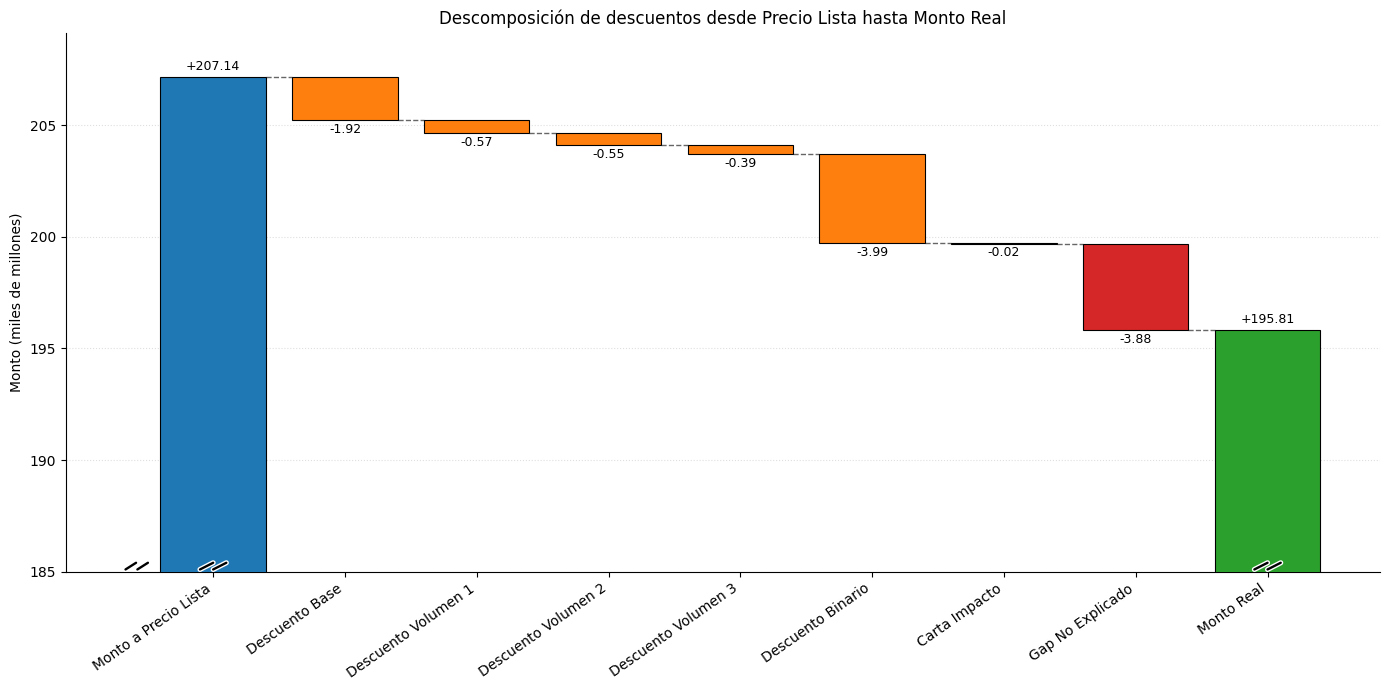

,concepto,valor
0,Monto a Precio Lista,2.071369e+11
1,Descuentos Explicados (sin forzados),7.444054e+09
2,Gap No Explicado (incluye forzados),3.881292e+09
3,Monto Real,1.958115e+11
4,% gap explicado,6.572915e-01


,etapa,valor,tipo
0,Monto a Precio Lista,2.071369e+11,total
1,Descuento Base,-1.922871e+09,change
2,Descuento Volumen 1,-5.658186e+08,change
3,Descuento Volumen 2,-5.455016e+08,change
4,Descuento Volumen 3,-3.946665e+08,change
5,Descuento Binario,-3.993527e+09,change
6,Carta Impacto,-2.166856e+07,change
7,Gap No Explicado,-3.881292e+09,change
8,Monto Real,1.958115e+11,total


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# =========================
# CONFIGURACIÓN
# =========================
Y_FLOOR = 185

# =========================
# DATOS BASE
# =========================
# Solo las categorías que se muestran como pasos explícitos (sin forzados)
categorias_descuento = [
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
]

labels_descuento = {
    "base": "Descuento Base",
    "volumen_1": "Descuento Volumen 1",
    "volumen_2": "Descuento Volumen 2",
    "volumen_3": "Descuento Volumen 3",
    "binario": "Descuento Binario",
    "carta_impacto": "Carta Impacto",
}

costos_explicados = (
    tabla_descuentos
    .set_index("descuento_aplicado")["costo_total_descuento"]
    .reindex(categorias_descuento, fill_value=0.0)
)

monto_a_precio_lista_total = ventas["monto_a_precio_lista"].sum()
monto_real_total = ventas["monto_real"].sum()
gap_total = monto_a_precio_lista_total - monto_real_total
descuentos_explicados_total = costos_explicados.sum()

# El gap ahora incluye los forzados implícitamente
gap_no_explicado = gap_total - descuentos_explicados_total

# =========================
# CONSTRUCCIÓN DEL WATERFALL
# =========================
waterfall_steps = [("Monto a Precio Lista", monto_a_precio_lista_total, "total")]
waterfall_steps.extend(
    (labels_descuento[c], -costos_explicados[c], "change")
    for c in categorias_descuento
)
waterfall_steps.append(("Gap No Explicado", -gap_no_explicado, "change"))
waterfall_steps.append(("Monto Real", monto_real_total, "total"))

waterfall_df = pd.DataFrame(waterfall_steps, columns=["etapa", "valor", "tipo"])
waterfall_df["running_after"] = np.nan
waterfall_df["bottom"] = 0.0
waterfall_df["height"] = 0.0

running = 0.0
for i, row in waterfall_df.iterrows():
    valor = row["valor"]
    if row["tipo"] == "total":
        waterfall_df.at[i, "bottom"] = 0.0
        waterfall_df.at[i, "height"] = valor
        running = valor
    else:
        next_running = running + valor
        waterfall_df.at[i, "bottom"] = min(running, next_running)
        waterfall_df.at[i, "height"] = abs(valor)
        running = next_running
    waterfall_df.at[i, "running_after"] = running

escala = 1e9
waterfall_df["bottom_plot"] = waterfall_df["bottom"] / escala
waterfall_df["height_plot"] = waterfall_df["height"] / escala
waterfall_df["valor_plot"] = waterfall_df["valor"] / escala
waterfall_df["running_plot"] = waterfall_df["running_after"] / escala
waterfall_df["top_plot"] = waterfall_df["bottom_plot"] + waterfall_df["height_plot"]

# Colores
colors = []
for _, row in waterfall_df.iterrows():
    if row["tipo"] == "total":
        colors.append("#1f77b4" if row["etapa"] == "Monto a Precio Lista" else "#2ca02c")
    elif row["etapa"] == "Gap No Explicado":
        colors.append("#d62728" if row["valor"] < 0 else "#ff9896")
    else:
        colors.append("#ff7f0e")


# =========================
# FUNCIONES AUXILIARES
# =========================
def add_break_marker(ax, patch, y_break, dx=0.10, dy=0.30, gap=0.10, lw=1.7):
    xc = patch.get_x() + patch.get_width() / 2
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [xc + shift - dx / 2, xc + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black", lw=lw, solid_capstyle="round",
            clip_on=False, zorder=8
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


def add_axis_break(ax, y_break, x_offset=-0.58, dx=0.08, dy=0.30, gap=0.09, lw=1.7):
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [x_offset + shift - dx / 2, x_offset + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black", lw=lw, solid_capstyle="round",
            clip_on=False, zorder=9
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal()
        ])


# =========================
# GRÁFICO
# =========================
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(waterfall_df))
bar_width = 0.8

bars = ax.bar(
    x, waterfall_df["height_plot"], bottom=waterfall_df["bottom_plot"],
    width=bar_width, color=colors, edgecolor="black", linewidth=0.8, zorder=3
)

for i in range(len(waterfall_df) - 1):
    y = waterfall_df.loc[i, "running_plot"]
    ax.plot(
        [x[i] + bar_width / 2, x[i + 1] - bar_width / 2],
        [y, y], color="#666666", linestyle="--", linewidth=1, zorder=2
    )

# =========================
# RANGO VISUAL
# =========================
if Y_FLOOR is None:
    running_max = max(waterfall_df["running_plot"].max(), waterfall_df["height_plot"].max())
    running_min = min(
        waterfall_df["running_plot"].min(),
        waterfall_df.loc[waterfall_df["tipo"] == "change", "bottom_plot"].min(),
        waterfall_df["height_plot"].iloc[-1]
    )
    span = running_max - running_min
    y_floor = running_min - max(span * 0.12, 0.8)
else:
    y_floor = Y_FLOOR

visible_max = max(waterfall_df["top_plot"].max(), waterfall_df["running_plot"].max())
y_top = visible_max + 2.0
ax.set_ylim(y_floor, y_top)

for patch, (_, row) in zip(bars, waterfall_df.iterrows()):
    cruza_recorte = (row["bottom_plot"] < y_floor) and (row["top_plot"] > y_floor)
    if cruza_recorte:
        add_break_marker(ax, patch, y_floor + 0.25)

add_axis_break(ax, y_floor + 0.25)

# =========================
# ETIQUETAS
# =========================
for i, row in waterfall_df.iterrows():
    valor_txt = f"{row['valor_plot']:+.2f}"
    if row["tipo"] == "total":
        y_text = row["top_plot"] + 0.18
        va = "bottom"
    else:
        if row["valor"] < 0:
            y_text = row["running_plot"] - 0.12
            va = "top"
        else:
            y_text = row["running_plot"] + 0.12
            va = "bottom"
    ax.text(x[i], y_text, valor_txt, ha="center", va=va, fontsize=9, zorder=10)

# =========================
# FORMATO
# =========================
ax.set_xticks(x)
ax.set_xticklabels(waterfall_df["etapa"], rotation=35, ha="right")
ax.set_ylabel("Monto (miles de millones)")
ax.set_title("Descomposición de descuentos desde Precio Lista hasta Monto Real")
ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


# =========================
# TABLAS DE APOYO
# =========================
resumen_waterfall = pd.DataFrame({
    "concepto": [
        "Monto a Precio Lista",
        "Descuentos Explicados (sin forzados)",
        "Gap No Explicado (incluye forzados)",
        "Monto Real",
        "% gap explicado",
    ],
    "valor": [
        monto_a_precio_lista_total,
        descuentos_explicados_total,
        gap_no_explicado,
        monto_real_total,
        np.nan if gap_total == 0 else descuentos_explicados_total / gap_total,
    ]
})

display(resumen_waterfall)
display(waterfall_df[["etapa", "valor", "tipo"]])

|                              -11.0 |  7.243238e+06 |
|                               -8.0 |  3.300046e+06 |
|                               -7.0 |  3.261808e+06 |
|                               -5.0 |  2.835920e+06 |
|                               -4.0 |  2.576528e+06 |
|                              -14.0 |  2.519511e+06 |
|                              -35.0 |  2.332237e+06 |
|                              -16.0 |  1.528530e+06 |
|                              -26.0 |  1.109108e+06 |
|                              -33.0 |  1.044035e+06 |
|                              -27.0 |  1.008424e+06 |
|                              -24.0 |  9.352760e+05 |
|                              -23.0 |  8.257741e+05 |
|                              -29.0 |  7.524448e+05 |
|                              -22.0 |  7.032658e+05 |
|                              -36.0 |  6.698456e+05 |
|                              -32.0 |  6.619072e+05 |
|                              -21.0 |  6.039176e+05 |
|                              -34.0 |  3.545996e+05 |
|                               -2.0 |  2.521934e+05 |
|                               -1.0 |  3.232758e+04 |
|                              -28.0 |  2.186800e+04 |
|                              -38.0 |  1.055740e+04 |
|                              -39.0 |  1.170000e+02 |
|                              -37.0 | -4.000000e+00 |

# Validación

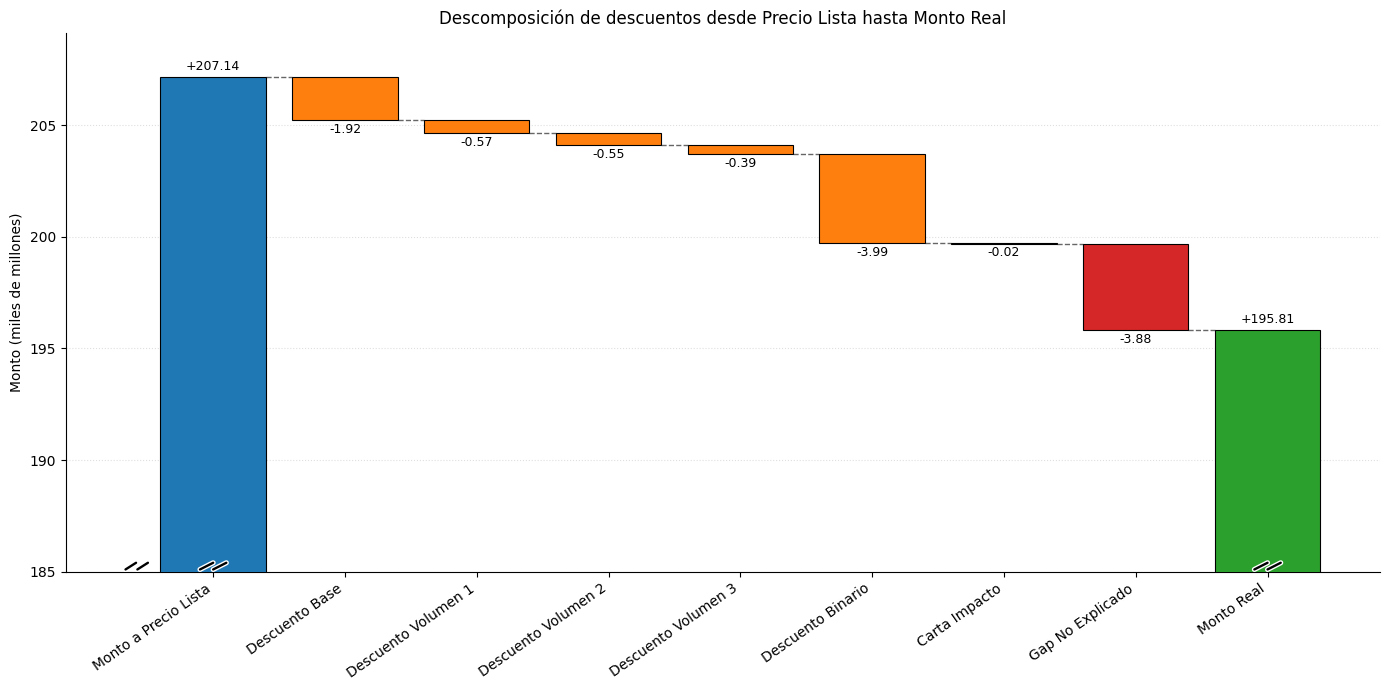

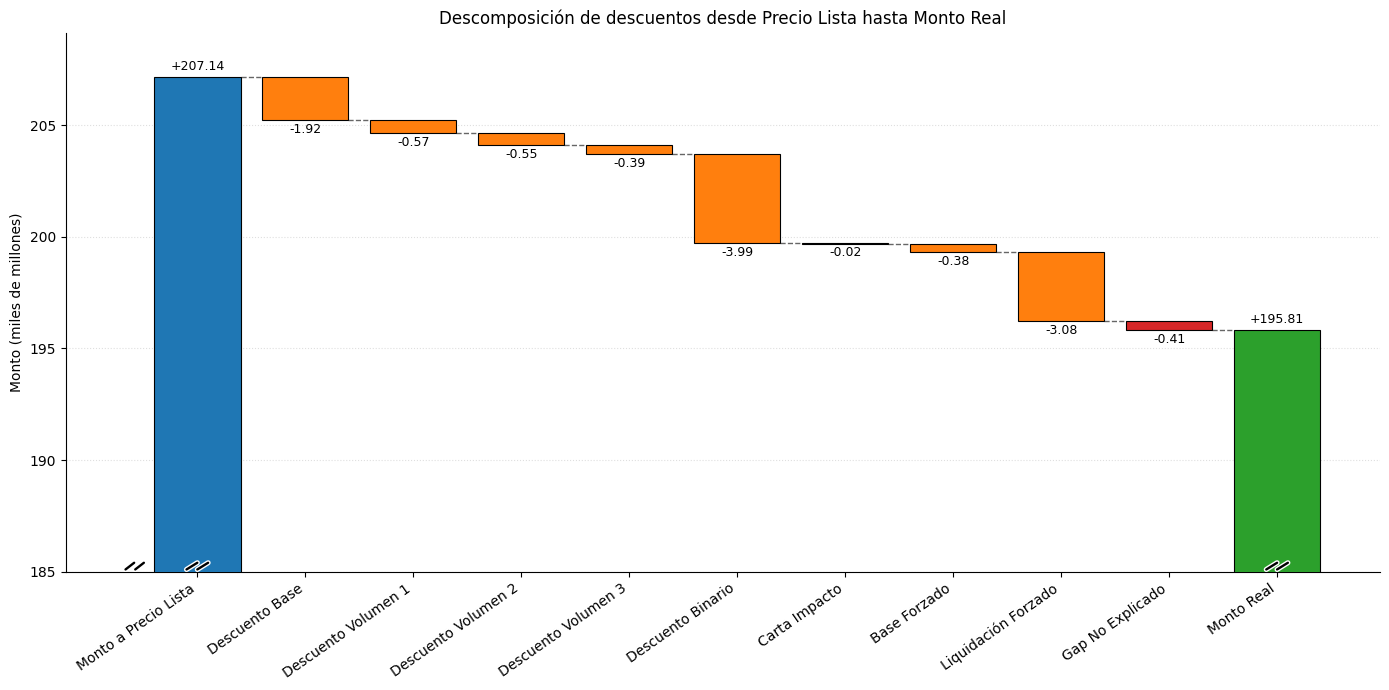


| % DSCTO OBSERVADO |         "COSTO" |
| ---------------------------------: | ------------: |
|                              -15.0 |  158 M |
|                              -10.0 |  85,9 M |
|                              -20.0 |  30,2 M |
|                              -17.0 |  25,1 M |
|                              -25.0 |  25,0 M |
|                              -18.0 |  18,7 M |
|                              -30.0 |  15,8 M |
|                              -19.0 |  10,5 M |
|                              -12.0 |  10,3 M |
|                               -9.0 |  10,2 M |
|                              -13.0 |  9,5 M |

